# Artificial Neural Networks (ANNs)

## Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


## `Layer` class and derived classes

- Only supports ReLU as of now, needs to be updated. 

In [ ]:
class Layer:
    def __init__(self, n_input: int, n_output: int):
        self.n_input = n_input
        self.n_output = n_output
        self.weights = np.random.randn(n_input, n_output) * 0.1 
        self.biases = np.random.randn(n_output)

    def activation(self, z):
        return np.maximum(0, z)
        
    def activation_derivative(self, z):
        return (z > 0).astype(float)
    
class Dense(Layer):
    def __init__(self, n_input, n_output):
        super().__init__(n_input, n_output)
        self.weights = np.random.randn(n_input, n_output) * 0.1 
        self.biases = np.random.randn(n_output)

class Dropout(Layer):
    def __init__(self, n_input):
        super().__init__(n_input, n_input)
        

## `ANN` Class

We implement ANNs using gradient descent for adaptive learning rate.

In [ ]:
class ANN:
    def __init__(self, n_neurons: list[int]):
        self.n_neurons = n_neurons
        self.layers = []
        self.n_features = 0
        self.n_out = 1

    def _init_layers(self):
        # [Input] -> [Hidden...] -> [Output]
        layer_sizes = [self.n_features] + self.n_neurons + [self.n_out]
        self.layers = []
        for i in range(1, len(layer_sizes)):
            self.layers.append(Layer(layer_sizes[i-1], layer_sizes[i]))

    def fit(self, X, y, n_iter=100, learning_rate=0.01):
        X = np.array(X)
        y = np.array(y).reshape(-1, 1) 
        
        self.n_features = X.shape[1]
        self.n_out = y.shape[1]
        self._init_layers()

        for _ in range(n_iter):
            A = X
            caches = []

            # 1. FORWARD PASS
            for layer in self.layers:
                A_prev = A
                Z = np.dot(A_prev, layer.weights) + layer.biases
                A = layer.activation(Z)
                caches.append((A_prev, Z))
            
            predictions = A
            
            # 2. BACKWARD PASS
            self.update_weights(predictions, y, caches, learning_rate)

    def update_weights(self, predictions, target, caches, learning_rate):
        m = target.shape[0]
        dA = 2 * (predictions - target) / m
        
        for i in reversed(range(len(self.layers))):
            layer = self.layers[i]
            A_prev, Z = caches[i]
            dZ = dA * layer.activation_derivative(Z)
            dW = np.dot(A_prev.T, dZ)
            db = np.sum(dZ, axis=0)
            dA = np.dot(dZ, layer.weights.T)
            layer.weights -= learning_rate * dW
            layer.biases -= learning_rate * db

    def predict(self, X):
        A = np.array(X)
        for layer in self.layers:
            Z = np.dot(A, layer.weights) + layer.biases
            A = layer.activation(Z)
        return A

## Test on synthetic data

Training the model...
Training complete!


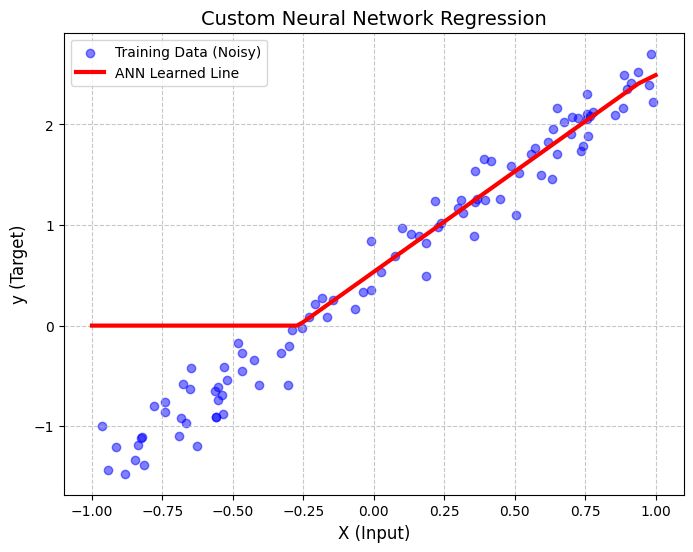

In [52]:
# np.random.seed(42)
X_train = np.random.uniform(-1, 1, (100, 1))
y_train = 2 * X_train + 0.5 + np.random.randn(100, 1) * 0.2

model = ANN(n_neurons=[10])

print("Training the model...")
model.fit(X_train, y_train, n_iter=1000, learning_rate=0.05)
print("Training complete!")

X_line = np.linspace(-1, 1, 100).reshape(-1, 1)
y_pred = model.predict(X_line)

plt.figure(figsize=(8, 6))
plt.scatter(X_train, y_train, color='blue', alpha=0.5, label='Training Data (Noisy)')
plt.plot(X_line, y_pred, color='red', linewidth=3, label='ANN Learned Line')
plt.title('Custom Neural Network Regression', fontsize=14)
plt.xlabel('X (Input)', fontsize=12)
plt.ylabel('y (Target)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [60]:
l = [1, 2, 3, 5, 6, 7]
l = np.array(l)
(l > 3).astype(float).reshape(-1, 1)

array([[0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [1.]])